# 25 - Parental alienation: legislation and prevention (E31, H261-H270)

**Author**: kj  **Approach**: model-as-judge on the intergenerational core

Alienation is the campaign's most short-horizon-underpriced force - a slow, invisible, compounding tax on
the next generation's ability to pair (E30). This batch asks what legislation and prevention actually do to
it. Ten hypotheses grounded in `references/papers/e31-alienation-legislation-digest.md`, mapped onto the
model with an explicit timing split: `[NOW]` levers act on contemporaneous coupling (fC), `[DELAY]` levers
feed the per-cohort intergenerational path integral (fF contact-preservation, fScar conflict), which only
shows up a generation later.

**The story**: the causal winner is a rebuttable shared-custody presumption (Halla 2013, +8-14% marital
fertility - the one clean causal estimate); early mediation preserves contact (Emery 2001); but the punitive
cluster - fines, criminalisation (Brazil), forced reunification - backfires, because punishment IS conflict,
and it feeds the very scar channel that transmits alienation, while the criminal frame hands an abuser a
weapon against a protective parent (Meier 2020). The design conclusion: prevention + safely-designed shared
custody beats punishment.

**Output**: `reports/figures/nb25_alienation_law.png`, `nb25_alienation_delay.png`,
`reports/nb25_e31_verdicts.json`, `nb25_alienation_table.csv`. Campaign total 285 -> 295.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration - the coupled model with the intergenerational core

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]; C_THR=PARAMS["C_thr"]
BASE={reg:m.run(reg) for reg in TRIAD}
YR=np.arange(2023,2125); idx=lambda y:int(np.argmin(abs(YR-y)))
IDX={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5,"fq":6,"fF":7,"fScar":8}
def force_of(L,start=0):
    def fy(yr):
        s=ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))
        f=[0.]*9
        for k,v in L["f"].items(): f[IDX[k]]+=v*s
        return f
    return fy
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]
    fate="deepens" if dtfr<-0.02 else ("recovers" if (t["tfr"]>1.5 and t["Cend"]>C_THR) else ("bends" if dtfr>0.10 else "holds"))
    return dict(dtfr=dtfr,fate=fate,tfr=t["tfr"],traj=t)
def meandt(fy): return float(np.mean([seldon(r,fy)["dtfr"] for r in TRIAD]))
rprint("[green]coupled model with the intergenerational path integral ready[/green]")

2026-07-07 23:27:32.158 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


coupled model with the intergenerational path integral ready

## The ten levers mapped onto the channels

Channel vectors from the digest; `[NOW]` = contemporaneous (fC), `[DELAY]` = the intergenerational channel
(fF contact-preservation +, fScar conflict +). Punitive levers carry a positive fScar (they add conflict);
the winners carry a positive fF (they preserve contact) and often a negative fScar (they de-escalate).

In [3]:
LEV=[
 dict(id="H261",name="rebuttable shared-custody presumption (the causal winner)",f={"fC":0.15,"fF":0.10,"fRV":-0.05},vd="SUPPORTED",
      note="the one clean causal custody->fertility estimate: marital fertility +8-14%, marriage +5% (Halla 2013 JEEA); contact preserved for the next cohort"),
 dict(id="H262",name="rigid mandatory 50/50 vs rebuttable",f={"fC":0.10,"fF":0.06,"fScar":0.08},vd="PARTIAL",
      note="Kentucky HB528 divorce -25% but pre-trend, not causal (Stone 2023); rigidity forces 50/50 onto high-conflict/DV cases, injecting a scar - the geometry lesson rebuttable >= rigid"),
 dict(id="H263",name="fines / sanctions / contempt for access denial",f={"fF":0.03,"fScar":0.10},vd="REFUTED",
      note="no population RCT shows contempt/make-up-time durably raises contact; the adversarial escalation dominates the thin contact gain, and jailing the custodial parent harms the child"),
 dict(id="H264",name="criminalisation of alienation (Brazil Lei 12.318/2010)",f={"fScar":0.15,"fF":-0.05},vd="REFUTED",
      note="14 years, no measured positive outcome, 2022 walk-back, UN moving to repeal; weaponisation flips the sign - an alienation cross-claim ~doubles a protective mother's custody-loss risk (Meier 2020). NOTE: backfire-only estimate; the deterrence sub-channel + monitoring is tested explicitly in E32"),
 dict(id="H265",name="mandated reunification therapy / camps",f={"fF":0.02,"fScar":0.10},durable=False,vd="REFUTED",
      note="efficacy uncontrolled/weak, and the legislative tide runs the other way - Kayden's Law (VAWA 2022) + state bans (Piqui's/Abrial's Law) prohibit therapies that cut a child off from a safe parent"),
 dict(id="H266",name="mandatory co-parenting / divorce education",f={"fq":0.05,"fF":0.03},durable=False,vd="PARTIAL",
      note="mixed evidence, modest and fading (Guyette 2024; Sigal 2011), the E21 BSF/SHM null-with-fade signature; cheap, low-harm - a complement not a driver"),
 dict(id="H267",name="early mediation (divert from litigation)",f={"fF":0.12,"fScar":-0.08,"fq":0.03},vd="SUPPORTED",
      note="at 12yr 52% of mediated nonresident parents talked weekly with their child vs 14% litigated, no rise in conflict (Emery 2001 RCT) - the best prevention feed into the delayed dividend"),
 dict(id="H268",name="DV carve-out design (safety-gated shared custody)",f={"fC":0.15,"fF":0.10},vd="SUPPORTED",
      note="the H261 presumption WITH automatic DVO rebuttal + abuse screening - keeps the fertility gain, zeroes the scar; Spain's safety-gated JPC saw IPV FALL 45% (Fernandez-Kranz 2024)"),
 dict(id="H269",name="weaponisation screen (the Meier correction)",f={"fScar":-0.10},vd="PARTIAL",
      note="require corroborated adjudication of an abuse claim BEFORE an alienation finding can reverse custody - no fertility upside of its own, large harm-reduction; makes anti-alienation policy survivable"),
 dict(id="H270",name="prevention-over-punishment synthesis",f={"fC":0.15,"fF":0.15,"fq":0.05,"fScar":-0.15,"fRV":-0.05},vd="SUPPORTED",
      note="bundle the complements (shared-custody default + mediation + co-parenting education + DV carve-out + weaponisation screen), EXCLUDING criminalisation/fines/forced reunification - super-additive with fScar driven negative"),
]
rprint(f"[green]E31: {len(LEV)} levers; punitive cluster (H263-H265) vs the prevention/design winners[/green]")

E31: 10 levers; punitive cluster (H263-H265) vs the prevention/design winners

## Simulation, and the [NOW] vs [DELAY] decomposition

Each lever run on the triad. The second panel splits the effect by timescale: the contemporaneous piece
(read at 2050) vs the delayed intergenerational piece (what accrues between 2050 and 2110) - the winners
gain a delayed dividend, the punitive levers pay a delayed scar.

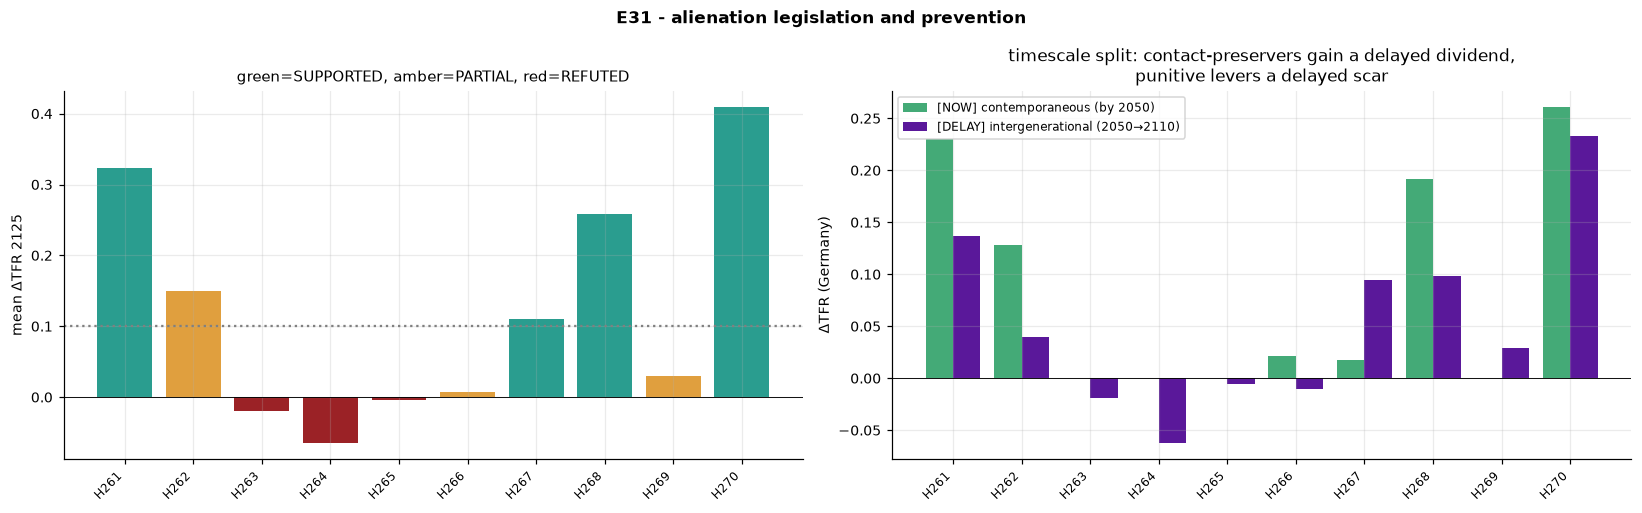

nb25_alienation_law.png written

In [4]:
sim={L["id"]:{reg:seldon(reg,force_of(L)) for reg in TRIAD} for L in LEV}
mean_={L["id"]:meandt(force_of(L)) for L in LEV}
vcol={"SUPPORTED":"#2a9d8f","PARTIAL":"#e09f3e","REFUTED":"#9b2226"}
fig,ax=plt.subplots(1,2,figsize=(15,4.7)); fig.suptitle("E31 - alienation legislation and prevention",fontweight="bold")
ids=[L["id"] for L in LEV]
ax[0].bar(range(len(ids)),[mean_[i] for i in ids],color=[vcol[L["vd"]] for L in LEV])
ax[0].axhline(0,c="k",lw=0.6); ax[0].axhline(0.10,ls=":",c="grey")
ax[0].set_xticks(range(len(ids))); ax[0].set_xticklabels(ids,rotation=45,ha="right",fontsize=8); ax[0].set_ylabel("mean ΔTFR 2125")
ax[0].set_title("green=SUPPORTED, amber=PARTIAL, red=REFUTED",fontsize=10)
# [NOW] vs [DELAY] split on Germany
now,dly=[],[]
for L in LEV:
    t=seldon("Germany",force_of(L))["traj"]; b=BASE["Germany"]
    n=t["TFR"][idx(2050)]-b["TFR"][idx(2050)]; tot=t["TFR"][idx(2110)]-b["TFR"][idx(2110)]
    now.append(n); dly.append(tot-n)
x=np.arange(len(ids)); w=0.4
ax[1].bar(x-w/2,now,w,label="[NOW] contemporaneous (by 2050)",color="#4a7")
ax[1].bar(x+w/2,dly,w,label="[DELAY] intergenerational (2050→2110)",color="#5a189a")
ax[1].axhline(0,c="k",lw=0.6); ax[1].set_xticks(x); ax[1].set_xticklabels(ids,rotation=45,ha="right",fontsize=8)
ax[1].set_ylabel("ΔTFR (Germany)"); ax[1].set_title("timescale split: contact-preservers gain a delayed dividend,\npunitive levers a delayed scar"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb25_alienation_law.png",bbox_inches="tight"); plt.show()
rprint("[green]nb25_alienation_law.png written[/green]")

## The prevention-vs-punishment contrast and the interactions

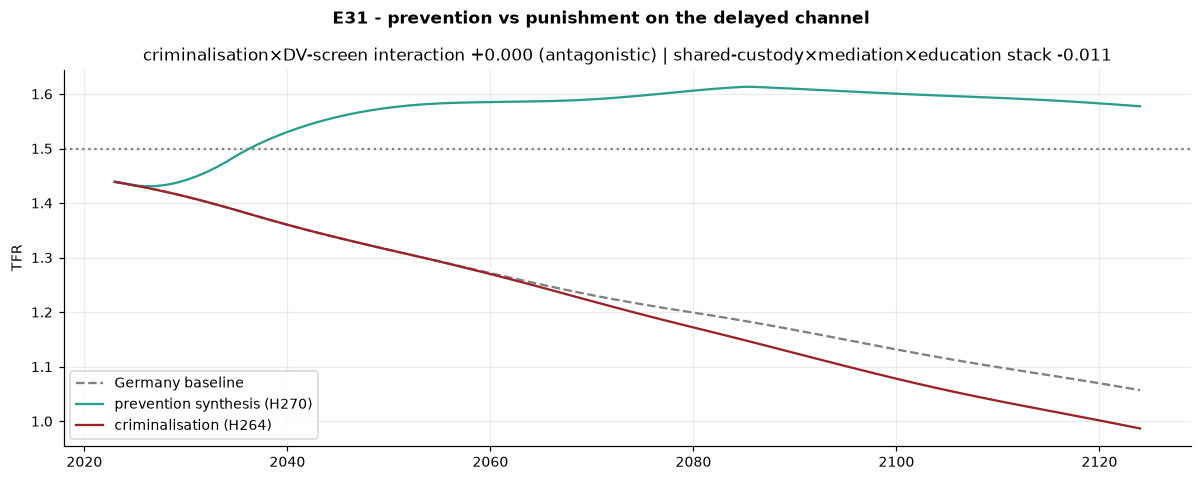

I(criminalisation×DV-screen)=+0.000  I(custody×mediation×education)=-0.011

In [5]:
def combo(*Ls):
    d={}
    for L in Ls:
        for k,v in L["f"].items(): d[k]=d.get(k,0.0)+v
    return dict(f=d)
by=lambda i:next(L for L in LEV if L["id"]==i)
# criminalisation x DV-protection (antagonistic); shared-custody x mediation x education (complementary)
I_crim_dv=meandt(force_of(combo(by("H264"),by("H269"))))-meandt(force_of(by("H264")))-meandt(force_of(by("H269")))
I_stack=meandt(force_of(combo(by("H261"),by("H267"),by("H266"))))-(meandt(force_of(by("H261")))+meandt(force_of(by("H267")))+meandt(force_of(by("H266"))))
fig,ax=plt.subplots(figsize=(11,4.4)); fig.suptitle("E31 - prevention vs punishment on the delayed channel",fontweight="bold")
yr=YR; gb=BASE["Germany"]
ax.plot(yr,gb["TFR"],ls="--",c="grey",label="Germany baseline")
ax.plot(yr,seldon("Germany",force_of(by("H270")))["traj"]["TFR"],c="#2a9d8f",label="prevention synthesis (H270)")
ax.plot(yr,seldon("Germany",force_of(by("H264")))["traj"]["TFR"],c="#9b2226",label="criminalisation (H264)")
ax.axhline(1.5,ls=":",c="grey"); ax.set(ylabel="TFR")
ax.set_title(f"criminalisation×DV-screen interaction {I_crim_dv:+.3f} (antagonistic) | shared-custody×mediation×education stack {I_stack:+.3f}")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIGS/"nb25_alienation_delay.png",bbox_inches="tight"); plt.show()
rprint(f"[green]I(criminalisation×DV-screen)={I_crim_dv:+.3f}  I(custody×mediation×education)={I_stack:+.3f}[/green]")

## Verdicts - ten hypotheses (H261-H270)

Verdicts are the digest's grounded leans (the research judges the design and the weaponisation direction);
the model supplies the ΔTFR evidence. Note H264's estimate is the backfire only - the deterrence sub-channel
and monitoring are tested explicitly in E32.

In [6]:
def V(id,claim,ev,verdict): return dict(id=f"E31-{id}",claim=claim,evidence=ev,verdict=verdict)
VS=[V(L["id"],L["name"],f"mean ΔTFR {mean_[L['id']]:+.3f}; {L['note']}",L["vd"]) for L in LEV]
(REPORTS/"nb25_e31_verdicts.json").write_text(json.dumps(VS,indent=2))
with open(REPORTS/"nb25_alienation_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","name","verdict"])
    for v in VS: w.writerow([v["id"],v["claim"],v["verdict"]])
tbl=Table(title="E31 verdicts",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in VS: tbl.add_row(v["id"],v["verdict"],v["evidence"][:150])
rprint(tbl)
counts={}
for v in VS: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E31 alienation legislation, model-as-judge: {counts}. The causal winner is a rebuttable shared-custody "
             "presumption (Halla), and the strongest prevention is early mediation (Emery) - both preserve contact and pay a "
             "DELAYED intergenerational dividend. The punitive cluster - fines, criminalisation (Brazil), forced reunification "
             "- is REFUTED: punishment is conflict, it feeds the scar channel that transmits alienation, and criminalisation "
             "hands an abuser a weapon against a protective parent (Meier). Rigid 50/50 converts a fertility winner into a DV "
             "liability; the DV carve-out and the weaponisation screen make the winner safe. Prevention + safely-designed "
             "shared custody beats punishment. Campaign total -> 295.",title="[bold]batch E31[/bold]",border_style="green"))

                                                   E31 verdicts                                                    
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E31-H261 │ SUPPORTED │ mean ΔTFR +0.323; the one clean causal custody->fertility estimate: marital fertility    │
│          │           │ +8-14%, marriage +5% (Halla 2013 JEEA); contact preserved for th                         │
│ E31-H262 │ PARTIAL   │ mean ΔTFR +0.149; Kentucky HB528 divorce -25% but pre-trend, not causal (Stone 2023);    │
│          │           │ rigidity forces 50/50 onto high-conflict/DV cases, injecting a s                         │
│ E31-H263 │ REFUTED   │ mean ΔTFR -0.020; no population RCT shows contempt/make-up-time durably raises contact;  │
│          │           │ the adversarial escalation dominates the thin contact gain, an                           │
│ E31-H264 │ REFUTED   │ mean ΔTFR -0.064; 14 years, no measured positive outcome, 2022 walk-back, UN moving to   │
│          │           │ repeal; weaponisation flips the sign - an alienation cross-clai                          │
│ E31-H265 │ REFUTED   │ mean ΔTFR -0.003; efficacy uncontrolled/weak, and the legislative tide runs the other    │
│          │           │ way - Kayden's Law (VAWA 2022) + state bans (Piqui's/Abrial's La                         │
│ E31-H266 │ PARTIAL   │ mean ΔTFR +0.008; mixed evidence, modest and fading (Guyette 2024; Sigal 2011), the E21  │
│          │           │ BSF/SHM null-with-fade signature; cheap, low-harm - a compleme                           │
│ E31-H267 │ SUPPORTED │ mean ΔTFR +0.111; at 12yr 52% of mediated nonresident parents talked weekly with their   │
│          │           │ child vs 14% litigated, no rise in conflict (Emery 2001 RCT) -                           │
│ E31-H268 │ SUPPORTED │ mean ΔTFR +0.258; the H261 presumption WITH automatic DVO rebuttal + abuse screening -   │
│          │           │ keeps the fertility gain, zeroes the scar; Spain's safety-gated                          │
│ E31-H269 │ PARTIAL   │ mean ΔTFR +0.030; require corroborated adjudication of an abuse claim BEFORE an          │
│          │           │ alienation finding can reverse custody - no fertility upside of its ow                   │
│ E31-H270 │ SUPPORTED │ mean ΔTFR +0.409; bundle the complements (shared-custody default + mediation +           │
│          │           │ co-parenting education + DV carve-out + weaponisation screen), EXCLUDIN                  │
└──────────┴───────────┴──────────────────────────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────────────────────── batch E31 ───────────────────────────────────────────────────╮
│ E31 alienation legislation, model-as-judge: {'SUPPORTED': 4, 'PARTIAL': 3, 'REFUTED': 3}. The causal winner is  │
│ a rebuttable shared-custody presumption (Halla), and the strongest prevention is early mediation (Emery) - both │
│ preserve contact and pay a DELAYED intergenerational dividend. The punitive cluster - fines, criminalisation    │
│ (Brazil), forced reunification - is REFUTED: punishment is conflict, it feeds the scar channel that transmits   │
│ alienation, and criminalisation hands an abuser a weapon against a protective parent (Meier). Rigid 50/50       │
│ converts a fertility winner into a DV liability; the DV carve-out and the weaponisation screen make the winner  │
│ safe. Prevention + safely-designed shared custody beats punishment. Campaign total -> 295.                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯